# From One Probability to Several

**Session 10 · companion to HW 2 · nothing here is a homework answer**

Logistic regression is a linear model with a squashing function on the end, and
almost everything that goes wrong with it goes wrong in one of three places:
the arithmetic overflows, the multiclass strategy is not the one you assumed,
or the threshold is left at 0.5 without anyone deciding that it should be.

This notebook is those three places. It deliberately does **not** implement the
stable sigmoid or the gradient — those are HW 2's, and writing them here would
take the assignment away from you.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit, logsumexp

rng = np.random.default_rng(5)

## 1. Where the naive formula breaks

`1 / (1 + exp(-z))` is correct mathematics and unsafe code. For strongly
negative `z`, `exp(-z)` overflows the float range long before the probability
becomes interesting.

In [2]:
z = np.array([-1000.0, -800.0, -50.0, 0.0, 50.0, 800.0])

with np.errstate(over="raise"):
    try:
        naive = 1 / (1 + np.exp(-z))
    except FloatingPointError as err:
        print("FloatingPointError:", err)

# Without the error state it does not crash -- it quietly returns 0.0
with np.errstate(over="ignore"):
    naive = 1 / (1 + np.exp(-z))
print("\nnaive :", naive)
print("expit :", expit(z))
print("\nagree?", np.allclose(naive, expit(z)))

FloatingPointError: overflow encountered in exp

naive : [0.00000000e+00 0.00000000e+00 1.92874985e-22 5.00000000e-01
 1.00000000e+00 1.00000000e+00]
expit : [0.00000000e+00 0.00000000e+00 1.92874985e-22 5.00000000e-01
 1.00000000e+00 1.00000000e+00]

agree? True


On this input the naive version happens to agree, because `inf` in the
denominator gives exactly 0.0 — the right answer for the wrong reason. Change
the expression slightly and the same overflow produces `nan` instead, and a
`nan` propagates through a gradient into every weight in the model.

In [3]:
with np.errstate(over="ignore", invalid="ignore"):
    # The same probability, written the other way round. Algebraically identical.
    other_form = np.exp(z) / (1 + np.exp(z))
print("exp(z) / (1 + exp(z)) :", other_form)
print("expit(z)              :", expit(z))
print("\nnan produced:", int(np.isnan(other_form).sum()), "of", other_form.size)

exp(z) / (1 + exp(z)) : [0.00000000e+00 0.00000000e+00 1.92874985e-22 5.00000000e-01
 1.00000000e+00            nan]
expit(z)              : [0.00000000e+00 0.00000000e+00 1.92874985e-22 5.00000000e-01
 1.00000000e+00 1.00000000e+00]

nan produced: 1 of 6


Two algebraically identical formulas, one of which returns `nan` for large
positive `z`. `scipy.special.expit` picks the safe branch for each sign, and
HW 2 asks you to do the same thing by hand — with a test that feeds it exactly
these values.

The same trick, one level up, is `logsumexp`, which is how softmax stays
stable:

In [4]:
scores = np.array([1000.0, 1001.0, 999.0])
with np.errstate(over="ignore", invalid="ignore"):
    naive_softmax = np.exp(scores) / np.exp(scores).sum()
stable_softmax = np.exp(scores - logsumexp(scores))
print("naive :", naive_softmax)
print("stable:", stable_softmax.round(4), " sum =", stable_softmax.sum().round(6))

naive : [nan nan nan]
stable: [0.2447 0.6652 0.09  ]  sum = 1.0


## 2. What the model actually predicts

A fitted logistic regression gives you a probability per class. The class label
is a second step — `argmax` for multiclass, a threshold for binary — and that
second step is a decision, not a property of the model.

In [5]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=1200, n_features=6, n_informative=4,
                           n_classes=3, n_clusters_per_class=1, random_state=5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

multinomial = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=2000)).fit(X_train, y_train)
proba = multinomial.predict_proba(X_test[:4])
print("probabilities for four test rows:")
print(np.round(proba, 3))
print("\nrow sums:", proba.sum(axis=1).round(6))
print("predicted labels:", multinomial.predict(X_test[:4]))

probabilities for four test rows:
[[0.504 0.092 0.405]
 [0.064 0.86  0.076]
 [0.939 0.005 0.056]
 [0.246 0.033 0.721]]

row sums: [1. 1. 1. 1.]
predicted labels: [0 1 0 2]


## 3. One-vs-rest is a different model

Since scikit-learn 1.5, `LogisticRegression` fits the multinomial (softmax)
model for multiclass problems. One-vs-rest is still available through
`OneVsRestClassifier`, and it is genuinely a different estimator: *K* separate
binary fits, each asking "this class or not?", with the probabilities
normalised afterwards.

They agree most of the time. Where they disagree is instructive.

In [6]:
from sklearn.multiclass import OneVsRestClassifier

ovr = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(LogisticRegression(max_iter=2000))).fit(X_train, y_train)

p_multi = multinomial.predict_proba(X_test)
p_ovr = ovr.predict_proba(X_test)

disagree = (p_multi.argmax(1) != p_ovr.argmax(1))
print(f"test accuracy  multinomial {multinomial.score(X_test, y_test):.4f}"
      f"   ovr {ovr.score(X_test, y_test):.4f}")
print(f"different label on {disagree.sum()} of {len(y_test)} rows "
      f"({disagree.mean():.1%})")
print(f"mean absolute probability difference: {np.abs(p_multi - p_ovr).mean():.4f}")
print(f"largest single probability difference: {np.abs(p_multi - p_ovr).max():.4f}")

test accuracy  multinomial 0.8056   ovr 0.8028
different label on 13 of 360 rows (3.6%)
mean absolute probability difference: 0.0581
largest single probability difference: 0.3712


In [7]:
if disagree.any():
    # among the rows where the two disagree on the LABEL, the widest gap
    idx = np.flatnonzero(disagree)
    i = int(idx[np.argmax(np.abs(p_multi[idx] - p_ovr[idx]).max(axis=1))])
    print("a row where the two strategies choose different labels:")
    print("  multinomial:", p_multi[i].round(3), "-> class", p_multi[i].argmax())
    print("  one-vs-rest:", p_ovr[i].round(3), "-> class", p_ovr[i].argmax())
    print("  true label :", y_test[i])

a row where the two strategies choose different labels:
  multinomial: [0.375 0.263 0.362] -> class 0
  one-vs-rest: [0.195 0.331 0.475] -> class 2
  true label : 0


The multinomial fit optimises all classes jointly, so its probabilities are
comparable by construction. One-vs-rest fits each class against everything else
and then normalises, which can leave two classifiers both confident. The
practical rule: **report which one you used**, because "logistic regression,
accuracy 0.87" is not a reproducible description of a multiclass model.

## 4. The threshold is a policy, not a default

Back to two classes, with the imbalance that makes thresholds matter: 6% of rows
are positive.

In [8]:
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score)

Xb, yb = make_classification(n_samples=4000, n_features=8, n_informative=5,
                             weights=[0.94, 0.06], random_state=7)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=0.3, random_state=0, stratify=yb)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xb_tr, yb_tr)
scores_te = clf.predict_proba(Xb_te)[:, 1]

print(f"positives in the test set: {yb_te.mean():.1%}")
print(f"accuracy of predicting 'never positive': {1 - yb_te.mean():.3f}")
print(f"accuracy of the model at threshold 0.5 : {clf.score(Xb_te, yb_te):.3f}")
print(f"ROC-AUC {roc_auc_score(yb_te, scores_te):.3f}   "
      f"average precision {average_precision_score(yb_te, scores_te):.3f}")

positives in the test set: 6.5%
accuracy of predicting 'never positive': 0.935
accuracy of the model at threshold 0.5 : 0.945
ROC-AUC 0.779   average precision 0.480


The model beats the do-nothing baseline by a hair on accuracy while being
enormously more useful — which is the entire argument against reporting accuracy
on imbalanced data.

Now sweep the threshold and watch what each choice costs:

In [9]:
print(f"{'threshold':>9} {'predicted +':>12} {'precision':>10} {'recall':>8} "
      f"{'missed':>7} {'false alarms':>13}")
for thr in (0.05, 0.10, 0.20, 0.30, 0.50, 0.70):
    pred = (scores_te >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_te, pred).ravel()
    precision = tp / (tp + fp) if tp + fp else float("nan")
    recall = tp / (tp + fn)
    print(f"{thr:>9.2f} {tp + fp:>12} {precision:>10.3f} {recall:>8.3f} "
          f"{fn:>7} {fp:>13}")

threshold  predicted +  precision   recall  missed  false alarms
     0.05          424      0.134    0.731      21           367
     0.10          190      0.258    0.628      29           141
     0.20           78      0.513    0.513      38            38
     0.30           47      0.660    0.397      47            16
     0.50           26      0.731    0.244      59             7
     0.70           16      0.875    0.179      64             2


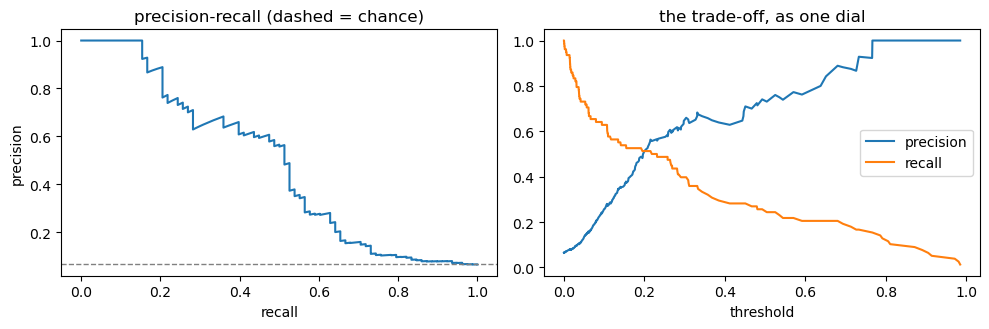

In [10]:
prec, rec, thresholds = precision_recall_curve(yb_te, scores_te)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(rec, prec)
ax[0].axhline(yb_te.mean(), ls="--", color="grey", lw=1)
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("precision-recall (dashed = chance)")

ax[1].plot(thresholds, prec[:-1], label="precision")
ax[1].plot(thresholds, rec[:-1], label="recall")
ax[1].set_xlabel("threshold"); ax[1].legend()
ax[1].set_title("the trade-off, as one dial")
plt.tight_layout(); plt.show()

There is no correct threshold on this page, because the correct threshold is a
property of the problem: what does a missed positive cost, and what does a false
alarm cost? A fraud screen and a cancer screen read the same curve and land in
different places.

Two rules that do hold:

- **Choose the threshold on validation data, never on the test set.** It is a
  parameter like any other, and choosing it on the test set spends the test set.
- **Report the threshold with the metric.** "Recall 0.83" is meaningless
  without it.

## 5. Averaging, when there are more than two classes

`f1_score` needs an `average=` for multiclass, and the choice changes what the
number means. Below, class 2 is deliberately rare.

In [11]:
from sklearn.metrics import classification_report, f1_score

Xm, ym = make_classification(n_samples=2000, n_features=8, n_informative=5,
                             n_classes=3, n_clusters_per_class=1,
                             weights=[0.6, 0.35, 0.05], random_state=2)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    Xm, ym, test_size=0.3, random_state=0, stratify=ym)
m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xm_tr, ym_tr)
pred_m = m.predict(Xm_te)

print(classification_report(ym_te, pred_m, digits=3))
print("macro    F1:", round(f1_score(ym_te, pred_m, average='macro'), 3),
      " <- every class counts the same")
print("weighted F1:", round(f1_score(ym_te, pred_m, average='weighted'), 3),
      " <- classes count by size")
print("micro    F1:", round(f1_score(ym_te, pred_m, average='micro'), 3),
      " <- equals accuracy for single-label problems")

              precision    recall  f1-score   support

           0      0.909     0.972     0.939       359
           1      0.940     0.886     0.912       211
           2      0.706     0.400     0.511        30

    accuracy                          0.913       600
   macro avg      0.851     0.753     0.787       600
weighted avg      0.910     0.913     0.908       600

macro    F1: 0.787  <- every class counts the same
weighted F1: 0.908  <- classes count by size
micro    F1: 0.913  <- equals accuracy for single-label problems


The macro average is the lower number, and it is lower precisely because the
rare class is hard. If the rare class is the one you care about — the fraud, the
fault, the disease — then the weighted average is the number that will let you
ship something that does not work.

## What to take from this

- Both closed forms of the sigmoid overflow, in opposite directions. The stable
  implementation branches on the sign; `logsumexp` is the same idea for softmax.
- Multinomial and one-vs-rest are different models with different probabilities.
  Name the one you used.
- Probabilities are the model's output; labels are your decision. The threshold
  belongs to the problem, is chosen on validation data, and is reported.
- With more than two classes, the averaging mode is part of the metric.

## Where to go next

- **Reading, Session 10** — the derivation of cross-entropy and its gradient.
- **`01_debugging_gradient_descent.ipynb`** — the numeric gradient check to run
  against your own HW 2 implementation.
- **Session 11** — metrics, cross-validation, and leakage in full.